
## <p style="background-color:#FDFEFE; font-family:newtimeroman; color:#060108; font-size:200%; text-align:center; border-radius:10px 10px;">The Capstone Project of Data Analytics Module</p>

## <p style="background-color:#9d4f8c; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">Columns</p>



**General Columns**
* url: url of autos
* short_description, description: Description of autos (in English and German) written by users

**Categorical Columns**
* make_model, make, model: Model of autos. Ex:Audi A1
* body_type, body: Body type of autos Example: van, sedans
* vat: VAT deductible, price negotiable
* registration, first_registration: First registration date and year of autos.
* prev_owner, previous_owners: Number of previous owners
* type: new or used
* next_inspection, inspection_new: information about inspection (inspection date,..)
* body_color, body_color_original: Color of auto Ex: Black, red
* paint_type: Paint type of auto Ex: Metallic, Uni/basic
* upholstery: Upholstery information (texture, color)
* gearing_type: Type of gear Ex: automatic, manual
* fuel : fuel type Ex: diesel, benzine
* co2_emission, emission_class, emission_label: emission information
* drive_chain: drive chain Ex: front,rear, 4WD
* consumption: consumption of auto in city, country and combination (lt/100 km)
* country_version
* entertainment_media
* safety_security
* comfort_convenience
* extras

**Quantitative Columns**
* price: Price of cars
* km: km of autos
* hp: horsepower of autos (kW)
* displacement: displacement of autos (cc)
* warranty: warranty period (month)
* weight: weight of auto (kg)
* nr_of_doors: number of doors
* nr_of_seats : number of seats
* cylinders: number of cylinders
* gears: number of gears



## <p style="background-color:#9d4f8c; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">Importing Libraries Needed</p>

In [1]:
import pandas as pd
import numpy as np
import json as js
import re
import seaborn as sns 
import matplotlib.pyplot as plt

## <p style="background-color:#9d4f8c; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">PART- 01- DATA CLEANING</p>

In [2]:
# Load the data set
file_path= "../data/raw/scout_car.json"
df = pd.read_json(file_path, lines=True)

#df.head().T - help to se the columns organized
df.head(3).T

,0,1,2
url,https://www.autoscout24.com//offers/audi-a1-sp...,https://www.autoscout24.com//offers/audi-a1-1-...,https://www.autoscout24.com//offers/audi-a1-sp...
make_model,Audi A1,Audi A1,Audi A1
short_description,Sportback 1.4 TDI S-tronic Xenon Navi Klima,1.8 TFSI sport,Sportback 1.6 TDI S tronic Einparkhilfe plus+m...
body_type,Sedans,Sedans,Sedans
price,15770,14500,14640
vat,VAT deductible,Price negotiable,VAT deductible
km,"56,013 km","80,000 km","83,450 km"
registration,01/2016,03/2017,02/2016
prev_owner,2 previous owners,None,1 previous owner
kW,NaN,NaN,NaN


In [3]:
# Check the data 
df.shape
#df.info()
#df.columns

(15919, 54)

In [4]:
df.isnull().sum()*100 / df.shape[0]

url                                0.000000
make_model                         0.000000
short_description                  0.288963
body_type                          0.376908
price                              0.000000
vat                               28.349771
km                                 0.000000
registration                       0.000000
prev_owner                        42.892141
kW                               100.000000
hp                                 0.000000
Type                               0.012564
Previous Owners                   41.711163
Next Inspection                   77.793831
Inspection new                    75.299956
Warranty                          34.047365
Full Service                      48.395000
Non-smoking Vehicle               54.915510
null                               0.000000
Make                               0.000000
Model                              0.000000
Offer Number                      19.944720
First Registration              

In [5]:
df.drop("null", axis=1, inplace=True)

In [6]:
# Data Cleanning

In [7]:
# The data set columns are problematic- they contain spaces, special characters(&, .), 
# hidden newline characters(\n).
# They are also inconsistent(some lowercase, some uppercase)

In [8]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace("\n", "", regex=False)
    .str.replace("&", "and", regex=False)
    .str.replace(".", "", regex=False)
    .str.replace(" ", "_")
)

df.columns

Index(['url', 'make_model', 'short_description', 'body_type', 'price', 'vat',
       'km', 'registration', 'prev_owner', 'kw', 'hp', 'type',
       'previous_owners', 'next_inspection', 'inspection_new', 'warranty',
       'full_service', 'non-smoking_vehicle', 'make', 'model', 'offer_number',
       'first_registration', 'body_color', 'paint_type', 'body_color_original',
       'upholstery', 'body', 'nr_of_doors', 'nr_of_seats', 'model_code',
       'gearing_type', 'displacement', 'cylinders', 'weight', 'drive_chain',
       'fuel', 'consumption', 'co2_emission', 'emission_class',
       'comfort_and_convenience', 'entertainment_and_media', 'extras',
       'safety_and_security', 'description', 'emission_label', 'gears',
       'country_version', 'electricity_consumption', 'last_service_date',
       'other_fuel_types', 'availability', 'last_timing_belt_service_date',
       'available_from'],
      dtype='object')

In [9]:
#Droping columns that have missing values more than %90.
def df_nans(df, limit):
    missing = df.isnull().sum()*100 / df.shape[0]
    return missing.loc[lambda x : x >= limit]

def column_nans(serial):
    # display percentage of nans in a Series
    return serial.isnull().sum()*100 / serial.shape[0]

In [10]:
df_nans(df, 90)

kw                               100.000000
electricity_consumption           99.139393
last_service_date                 96.444500
other_fuel_types                  94.472015
availability                      96.011056
last_timing_belt_service_date     99.899491
available_from                    98.291350
dtype: float64

In [11]:
column_nans(df["electricity_consumption"])

99.13939317796344

In [12]:
drop_columns = df_nans(df, 90).index
drop_columns

Index(['kw', 'electricity_consumption', 'last_service_date',
       'other_fuel_types', 'availability', 'last_timing_belt_service_date',
       'available_from'],
      dtype='object')

In [13]:
df.drop(drop_columns, axis=1, inplace=True)

In [14]:
df.columns

Index(['url', 'make_model', 'short_description', 'body_type', 'price', 'vat',
       'km', 'registration', 'prev_owner', 'hp', 'type', 'previous_owners',
       'next_inspection', 'inspection_new', 'warranty', 'full_service',
       'non-smoking_vehicle', 'make', 'model', 'offer_number',
       'first_registration', 'body_color', 'paint_type', 'body_color_original',
       'upholstery', 'body', 'nr_of_doors', 'nr_of_seats', 'model_code',
       'gearing_type', 'displacement', 'cylinders', 'weight', 'drive_chain',
       'fuel', 'consumption', 'co2_emission', 'emission_class',
       'comfort_and_convenience', 'entertainment_and_media', 'extras',
       'safety_and_security', 'description', 'emission_label', 'gears',
       'country_version'],
      dtype='object')

In [15]:
df.head()

,url,make_model,short_description,body_type,price,vat,km,registration,prev_owner,hp,...,co2_emission,emission_class,comfort_and_convenience,entertainment_and_media,extras,safety_and_security,description,emission_label,gears,country_version
0,https://www.autoscout24.com//offers/audi-a1-sp...,Audi A1,Sportback 1.4 TDI S-tronic Xenon Navi Klima,Sedans,15770,VAT deductible,"56,013 km",01/2016,2 previous owners,66 kW,...,[\n99 g CO2/km (comb)\n],[\nEuro 6\n],"[Air conditioning, Armrest, Automatic climate ...","[Bluetooth, Hands-free equipment, On-board com...","[Alloy wheels, Catalytic Converter, Voice Cont...","[ABS, Central door lock, Daytime running light...","[\n, Sicherheit:, , Deaktivierung für Beifahr...",NaN,NaN,NaN
1,https://www.autoscout24.com//offers/audi-a1-1-...,Audi A1,1.8 TFSI sport,Sedans,14500,Price negotiable,"80,000 km",03/2017,None,141 kW,...,[\n129 g CO2/km (comb)\n],[\nEuro 6\n],"[Air conditioning, Automatic climate control, ...","[Bluetooth, Hands-free equipment, On-board com...","[Alloy wheels, Sport seats, Sport suspension, ...","[ABS, Central door lock, Central door lock wit...",[\nLangstreckenfahrzeug daher die hohe Kilomet...,[\n4 (Green)\n],[\n7\n],NaN
2,https://www.autoscout24.com//offers/audi-a1-sp...,Audi A1,Sportback 1.6 TDI S tronic Einparkhilfe plus+m...,Sedans,14640,VAT deductible,"83,450 km",02/2016,1 previous owner,85 kW,...,[\n99 g CO2/km (comb)\n],[\nEuro 6\n],"[Air conditioning, Cruise control, Electrical ...","[MP3, On-board computer]","[Alloy wheels, Voice Control]","[ABS, Central door lock, Daytime running light...","[\n, Fahrzeug-Nummer: AM-95365, , Ehem. UPE 2...",[\n4 (Green)\n],NaN,NaN
3,https://www.autoscout24.com//offers/audi-a1-1-...,Audi A1,1.4 TDi Design S tronic,Sedans,14500,None,"73,000 km",08/2016,1 previous owner,66 kW,...,[\n99 g CO2/km (comb)\n],[\nEuro 6\n],"[Air suspension, Armrest, Auxiliary heating, E...","[Bluetooth, CD player, Hands-free equipment, M...","[Alloy wheels, Sport seats, Voice Control]","[ABS, Alarm system, Central door lock with rem...","[\nAudi A1: , - 1e eigenaar , - Perfecte staat...",NaN,[\n6\n],NaN
4,https://www.autoscout24.com//offers/audi-a1-sp...,Audi A1,Sportback 1.4 TDI S-Tronic S-Line Ext. admired...,Sedans,16790,None,"16,200 km",05/2016,1 previous owner,66 kW,...,[\n109 g CO2/km (comb)\n],[\nEuro 6\n],"[Air conditioning, Armrest, Automatic climate ...","[Bluetooth, CD player, Hands-free equipment, M...","[Alloy wheels, Sport package, Sport suspension...","[ABS, Central door lock, Driver-side airbag, E...","[\n, Technik & Sicherheit:, Xenon plus, Klimaa...",NaN,NaN,[\nGermany\n]


In [16]:
df.drop('url', axis=1, inplace=True)

In [17]:
df_nans(df, 90)

Series([], dtype: float64)

In [18]:
#df.head(3).T

## <p style="background-color:#9d4f8c; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">The Examination of Columns</p>

In [19]:
df.make_model.value_counts(dropna=False)

Audi A3           3097
Audi A1           2614
Opel Insignia     2598
Opel Astra        2526
Opel Corsa        2219
Renault Clio      1839
Renault Espace     991
Renault Duster      34
Audi A2              1
Name: make_model, dtype: int64

In [20]:
df.make.value_counts(dropna=False)

\nOpel\n       7343
\nAudi\n       5712
\nRenault\n    2864
Name: make, dtype: int64

In [21]:
df["make"]= df.make.str.strip('\n')

In [22]:
df.make.value_counts(dropna=False)

Opel       7343
Audi       5712
Renault    2864
Name: make, dtype: int64

In [23]:
df["model"][0][1]

'A1'

In [24]:
df["model"].apply(lambda x: x[1])

0            A1
1            A1
2            A1
3            A1
4            A1
          ...  
15914    Espace
15915    Espace
15916    Espace
15917    Espace
15918    Espace
Name: model, Length: 15919, dtype: object

In [25]:
df.model.str[1]

0            A1
1            A1
2            A1
3            A1
4            A1
          ...  
15914    Espace
15915    Espace
15916    Espace
15917    Espace
15918    Espace
Name: model, Length: 15919, dtype: object

In [26]:
# After the examination, we have decided to drop the columns, "Make" & "Model" and kept the column of "make_model.
df.drop(["make","model"], axis= 1, inplace = True)

In [27]:
df.columns

Index(['make_model', 'short_description', 'body_type', 'price', 'vat', 'km',
       'registration', 'prev_owner', 'hp', 'type', 'previous_owners',
       'next_inspection', 'inspection_new', 'warranty', 'full_service',
       'non-smoking_vehicle', 'offer_number', 'first_registration',
       'body_color', 'paint_type', 'body_color_original', 'upholstery', 'body',
       'nr_of_doors', 'nr_of_seats', 'model_code', 'gearing_type',
       'displacement', 'cylinders', 'weight', 'drive_chain', 'fuel',
       'consumption', 'co2_emission', 'emission_class',
       'comfort_and_convenience', 'entertainment_and_media', 'extras',
       'safety_and_security', 'description', 'emission_label', 'gears',
       'country_version'],
      dtype='object')

In [28]:
df['short_description']

0              Sportback 1.4 TDI S-tronic Xenon Navi Klima
1                                           1.8 TFSI sport
2        Sportback 1.6 TDI S tronic Einparkhilfe plus+m...
3                                  1.4 TDi Design S tronic
4        Sportback 1.4 TDI S-Tronic S-Line Ext. admired...
                               ...                        
15914                Blue dCi 200CV EDC Executive 4Control
15915                  TCe 225 EDC GPF LIM Deluxe Pano,RFK
15916    Blue dCi 200 EDC Initiale Paris Leder LED Navi...
15917    Blue dCi 200CV EDC Business , NUOVA DA IMMATRI...
15918          INITIALE PARIS TCe 225 EDC GPF NAVI SHZ AUX
Name: short_description, Length: 15919, dtype: object

In [29]:
df.drop("short_description", axis=1, inplace=True)

In [30]:
df['description']

0        [\n, Sicherheit:,  , Deaktivierung für Beifahr...
1        [\nLangstreckenfahrzeug daher die hohe Kilomet...
2        [\n, Fahrzeug-Nummer: AM-95365,  , Ehem. UPE 2...
3        [\nAudi A1: , - 1e eigenaar , - Perfecte staat...
4        [\n, Technik & Sicherheit:, Xenon plus, Klimaa...
                               ...                        
15914    [\nVettura visionabile nella sede in Via Roma ...
15915    [\nDach: Panorama-Glas-Schiebedach, Lackierung...
15916    [\n, Getriebe:,  Automatik, Technik:,  Bordcom...
15917    [\nDEK:[2691331], Renault Espace Blue dCi 200C...
15918    [\n, Sicherheit Airbags:,  , Seitenairbag,  , ...
Name: description, Length: 15919, dtype: object

In [31]:
df['description'].astype('str').value_counts(dropna=False)

[]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

In [32]:
df.drop("description", axis=1, inplace=True)

**Note: Even if the columns of "short_description" & "description" contain detailed information, we do NOT need it since this information can be obtained from other features.**

In [33]:
df.body_type.value_counts(dropna=False)

Sedans           7903
Station wagon    3553
Compact          3153
Van               783
Other             290
Transporter        88
None               60
Off-Road           56
Coupe              25
Convertible         8
Name: body_type, dtype: int64

In [34]:
df.body.astype('str').value_counts(dropna=False)

['\n', 'Sedans', '\n']           7903
['\n', 'Station wagon', '\n']    3553
['\n', 'Compact', '\n']          3153
['\n', 'Van', '\n']               783
['\n', 'Other', '\n']             290
['\n', 'Transporter', '\n']        88
nan                                60
['\n', 'Off-Road', '\n']           56
['\n', 'Coupe', '\n']              25
['\n', 'Convertible', '\n']         8
Name: body, dtype: int64

In [35]:
# Both the columns of "body_type" & "Body" have the same information, 
# we will keep the "body_type" column which is more readable.
df.drop("body", axis = 1, inplace = True)

In [36]:
# Price

In [37]:
df.price.value_counts(dropna=False)

14990    154
15990    151
10990    139
15900    106
17990    102
        ... 
17559      1
17560      1
17570      1
17575      1
39875      1
Name: price, Length: 2956, dtype: int64

In [38]:
df.price.isnull().sum()

0

/Users/sibelsezen/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='price'>

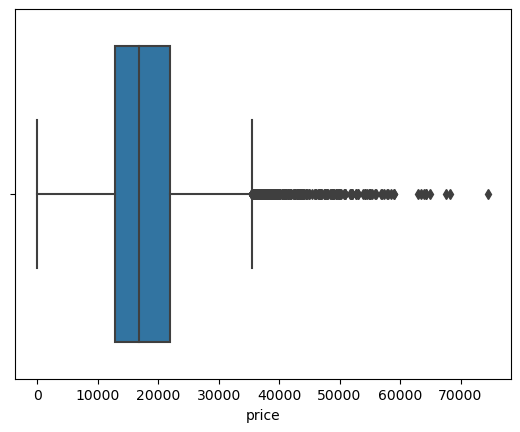

In [39]:
sns.boxplot(df.price)

/Users/sibelsezen/opt/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='price', ylabel='Density'>

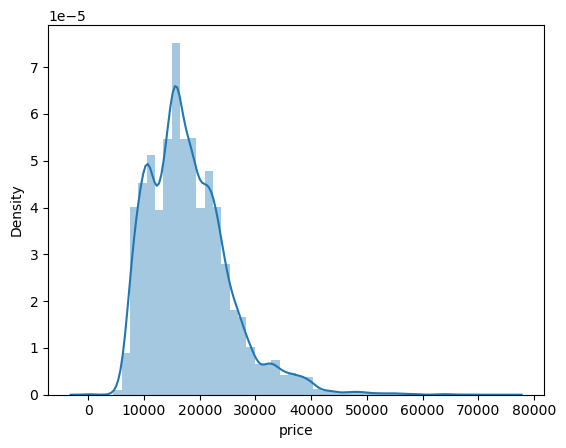

In [40]:
sns.distplot(df.price)

In [41]:
# Vat

In [42]:
df.vat.value_counts(dropna=False)

VAT deductible      10980
None                 4513
Price negotiable      426
Name: vat, dtype: int64

In [43]:
# Clean strings and commas, then convert to numeric of km
df["km"] = (
    df["km"]
    .astype(str)
    .str.replace("km", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["km"] = pd.to_numeric(df["km"], errors="coerce")

In [44]:
df.km.value_counts(dropna=False)

10.0       1045
NaN        1024
1.0         367
5.0         170
50.0        148
           ... 
67469.0       1
43197.0       1
10027.0       1
35882.0       1
57.0          1
Name: km, Length: 6690, dtype: int64

In [45]:
# registration

In [46]:
df.registration.value_counts(dropna=False)

-/-        1597
03/2018     695
02/2019     585
05/2018     572
03/2019     543
01/2019     541
04/2018     541
02/2018     539
03/2016     536
04/2016     532
06/2018     532
01/2018     511
04/2019     506
02/2016     472
03/2017     471
05/2016     459
06/2016     452
05/2019     440
06/2017     409
05/2017     404
07/2018     396
04/2017     380
01/2016     376
02/2017     368
01/2017     306
08/2018     285
06/2019     224
07/2017     215
11/2017     180
07/2016     176
10/2016     160
10/2017     154
09/2017     149
11/2016     142
09/2018     141
09/2016     141
12/2016     134
12/2017     123
08/2017     114
11/2018     110
12/2018     103
10/2018      97
08/2016      94
07/2019       6
09/2019       5
08/2019       1
11/2019       1
12/2019       1
Name: registration, dtype: int64

In [47]:
# Clean firt_registration
df["first_registration"] = (
    df["first_registration"]
    .astype(str)
    .str.extract(r"(\d{4})")
)


In [48]:
# Clean registration and create age, because age is more useful than registration

df["registration_year"] = (
    df["registration"]
    .astype(str)
    .str.extract(r"(\d{4})")
)

df["registration_year"] = pd.to_numeric(df["registration_year"], errors="coerce")

df["age"] = 2019 - df["registration_year"]

In [49]:
df.age.value_counts(dropna=False)

1.0    4522
3.0    3674
2.0    3273
0.0    2853
NaN    1597
Name: age, dtype: int64

In [50]:
df.drop(["registration", "first_registration"], axis=1, inplace=True)

In [51]:
# prev_owner & Previous Owners

In [52]:
df[["previous_owners","prev_owner"]]

,previous_owners,prev_owner
0,\n2\n,2 previous owners
1,NaN,None
2,\n1\n,1 previous owner
3,\n1\n,1 previous owner
4,\n1\n,1 previous owner
...,...,...
15914,NaN,None
15915,"[\n1\n, \n, 7.4 l/100 km (comb), \n, 9.2 l/100...",1 previous owner
15916,"[\n1\n, \n139 g CO2/km (comb)\n]",1 previous owner
15917,NaN,None


In [53]:
# "previous_owners" and "prev_owner" describe same thing, they will need to merge

df["previous_owners"] = df["previous_owners"].combine_first(df["prev_owner"])

df["previous_owners"] = (
    df["previous_owners"]
    .astype(str)
    .str.extract(r"(\d+)")
)

df["previous_owners"] = pd.to_numeric(df["previous_owners"], errors="coerce")

df = df.drop(columns=["prev_owner"], errors="ignore")

In [54]:
df["previous_owners"].value_counts(dropna=False)

1.0    8294
NaN    6640
2.0     778
0.0     188
3.0      17
4.0       2
Name: previous_owners, dtype: int64

In [55]:
df.drop("previous_owners", axis=1, inplace= True)

In [56]:
# Clean hp and convert to numeric
df["hp"] = (
    df["hp"]
    .astype(str)
    .str.extract(r"(\d+)")
)

df["hp"] = pd.to_numeric(df["hp"], errors="coerce")

In [57]:
df.hp.value_counts(dropna=False)

85.0     2542
66.0     2122
81.0     1402
100.0    1308
110.0    1112
         ... 
84.0        1
195.0       1
44.0        1
239.0       1
9.0         1
Name: hp, Length: 81, dtype: int64

In [58]:
# Type

In [59]:
df.type.astype('str').value_counts()

['', 'Used', '', 'Diesel (Particulate Filter)']                                                                                 3475
['', 'Used', '', 'Diesel']                                                                                                      2516
['', 'Used', '', 'Gasoline']                                                                                                    2367
['', 'Used', '', 'Super 95']                                                                                                    1818
['', 'Pre-registered', '', 'Super 95']                                                                                           500
                                                                                                                                ... 
['', 'New', '', 'Regular/Benzine 91 / Super 95 / Super Plus 98 / Regular/Benzine E10 91 / Super Plus E10 98 / Super E10 95']       1
['', 'Used', '', 'Super 95 / Super Plus 98 / Super E10 95 / Super Plu

In [60]:
df["type"] = df.type.str[1]

In [61]:
df['type'].value_counts(dropna=False)

Used              11096
New                1650
Pre-registered     1364
Employee's car     1011
Demonstration       796
NaN                   2
Name: type, dtype: int64

In [62]:
# Next Inspection & Inspection new

In [63]:
df["inspection_new"].astype('str').value_counts(dropna=False)

nan                                                                                                            11987
['\nYes\n', '\nEuro 6\n']                                                                                        523
\nYes\n                                                                                                          362
['\nYes\n', '\n102 g CO2/km (comb)\n']                                                                           174
['\nYes\n', '\n4 (Green)\n']                                                                                     166
                                                                                                               ...  
['\nYes\n', '\n', '6 l/100 km (comb)', '\n', '8 l/100 km (city)', '\n', '4.9 l/100 km (country)', '\n']            1
['\nYes\n', '\n', '6.8 l/100 km (comb)', '\n', '8.5 l/100 km (city)', '\n', '6.1 l/100 km (country)', '\n']        1
['\nYes\n', '\n', '4.1 l/100 km (comb)', '\n', '7.5 l/100 km (ci

In [64]:
df["inspection_new"] = [item[0] if type(item) == list else item for item in df["inspection_new"]]

df["inspection_new"] = df["inspection_new"].str.strip("\n")

In [65]:
df["inspection_new"].value_counts(dropna=False)

NaN    11987
Yes     3932
Name: inspection_new, dtype: int64

In [66]:
df.drop(["next_inspection"], axis=1, inplace=True)

In [67]:
# warranty

In [68]:
df.warranty.astype('str').value_counts(dropna=False)

nan                                                                                                                5420
['\n', '\n', '\nEuro 6\n']                                                                                         1868
\n12 months\n                                                                                                      1177
\n                                                                                                                  979
\n24 months\n                                                                                                       566
                                                                                                                   ... 
['\n72 months\n', '\n125 g CO2/km (comb)\n']                                                                          1
['\n60 months\n', '\n14 g CO2/km (comb)\n']                                                                           1
['\n24 months\n', '\n121 g CO2/km (comb)

In [69]:
# Clean warranty - exract warranty
df["warranty"] = (
    df["warranty"]
    .astype(str)
    .str.extract(r"(\d+)")
)

df["warranty"] = pd.to_numeric(df["warranty"], errors="coerce")

In [70]:
df.warranty.astype('str').value_counts(dropna=False)

nan      6764
12.0     2595
6.0      2394
24.0     1118
4.0       530
         ... 
131.0       1
15.0        1
155.0       1
7.0         1
161.0       1
Name: warranty, Length: 124, dtype: int64

In [71]:
# Full Service

In [72]:
df.full_service.astype('str').value_counts(dropna=False)

nan                                                                                                             7704
['\n', '\n', '\n4 (Green)\n']                                                                                   2235
['\n', '\n', '\nEuro 6\n']                                                                                      2097
['\n', '\n']                                                                                                    1702
['\n', '\n', '\nEuro 6d-TEMP\n']                                                                                 399
                                                                                                                ... 
['\n', '\n', '\n80 g CO2/km (comb)\n']                                                                             1
['\n', '\n', '\n84 g CO2/km (comb)\n']                                                                             1
['\n', '\n', '\n', '6 l/100 km (comb)', '\n', '8 l/100 km (city)

In [73]:
df.drop("full_service", axis=1, inplace=True)

In [74]:
# Non-smoking Vehicle

In [75]:
df["non-smoking_vehicle"]

0                       [\n, \n]
1                            NaN
2                            NaN
3           [\n, \n, \nEuro 6\n]
4                       [\n, \n]
                  ...           
15914                        NaN
15915    [\n, \n, \n4 (Green)\n]
15916                   [\n, \n]
15917                        NaN
15918                        NaN
Name: non-smoking_vehicle, Length: 15919, dtype: object

In [76]:
df.drop("non-smoking_vehicle", axis=1, inplace=True)

In [77]:
# Offer Number

In [78]:
df.offer_number.astype('str').value_counts(dropna=False)

nan                                                 3175
['\nLT67679\n']                                       27
['\nUN89904\n']                                       27
['\nXJ38068\n']                                       27
['\nJV03654\n']                                       27
                                                    ... 
['\n160_dcbb6c3e-a6da-43a3-8754-ccd994cec93b\n']       1
['\n6701576\n']                                        1
['\n6701569\n']                                        1
['\n158121\n']                                         1
['\nRe_30000008029\n']                                 1
Name: offer_number, Length: 11441, dtype: int64

In [79]:
df.drop("offer_number", axis=1, inplace=True)

In [80]:
# body_color

In [81]:
df['body_color'].astype('str').value_counts(dropna=False)

['\n', 'Black', '\n']     3745
['\n', 'Grey', '\n']      3505
['\n', 'White', '\n']     3406
['\n', 'Silver', '\n']    1647
['\n', 'Blue', '\n']      1431
['\n', 'Red', '\n']        957
nan                        597
['\n', 'Brown', '\n']      289
['\n', 'Green', '\n']      154
['\n', 'Beige', '\n']      108
['\n', 'Yellow', '\n']      51
['\n', 'Violet', '\n']      18
['\n', 'Bronze', '\n']       6
['\n', 'Orange', '\n']       3
['\n', 'Gold', '\n']         2
Name: body_color, dtype: int64

In [82]:
df['body_color'] = df['body_color'].str[1]

In [83]:
df['body_color'].isnull().sum()

597

In [84]:
df['body_color'].astype('str').value_counts(dropna=False)

Black     3745
Grey      3505
White     3406
Silver    1647
Blue      1431
Red        957
nan        597
Brown      289
Green      154
Beige      108
Yellow      51
Violet      18
Bronze       6
Orange       3
Gold         2
Name: body_color, dtype: int64

In [85]:
#df.drop("body_color", axis=1, inplace=True)

In [86]:
# Body Color Original

In [87]:
df['body_color_original'].astype('str').value_counts(dropna=False)

nan                                      3759
['\nOnyx Schwarz\n']                      338
['\nBianco\n']                            282
['\nMythosschwarz Metallic\n']            238
['\nBrillantschwarz\n']                   216
                                         ... 
['\nRouge-Braun (G0Y)\n']                   1
['\nVARI COLRI DISPONIBILI\n']              1
['\nKokosnussbraun Metallic\n']             1
['\nFarbe frei wählbar\n']                  1
['\nPerlmutt-Weiß Metallic (Weiß)\n']       1
Name: body_color_original, Length: 1928, dtype: int64

In [88]:
df['body_color_original'] = df['body_color_original'].str[0].str[1:-1]

In [89]:
df['body_color_original'].isnull().sum()

3759

In [90]:
df['body_color_original'].astype('str').value_counts(dropna=False)

nan                              3759
Onyx Schwarz                      338
Bianco                            282
Mythosschwarz Metallic            238
Brillantschwarz                   216
                                 ... 
Rouge-Braun (G0Y)                   1
VARI COLRI DISPONIBILI              1
Kokosnussbraun Metallic             1
Farbe frei wählbar                  1
Perlmutt-Weiß Metallic (Weiß)       1
Name: body_color_original, Length: 1928, dtype: int64

In [91]:
df.drop('body_color_original',axis=1,inplace=True)

In [92]:
# paint_type

In [93]:
df['paint_type'].astype('str').value_counts(dropna=False)

['\nMetallic\n']       9794
nan                    5772
['\nUni/basic\n']       347
['\nPerl effect\n']       6
Name: paint_type, dtype: int64

In [94]:
df['paint_type'] = df['paint_type'].str[0].str[1:-1]

In [95]:
df['paint_type'].astype('str').value_counts(dropna=False)

Metallic       9794
nan            5772
Uni/basic       347
Perl effect       6
Name: paint_type, dtype: int64

In [96]:
# 'upholstery'

In [97]:
df["upholstery"] = [item[0] if type(item) == list else item for item in df.upholstery]

In [98]:
df["upholstery"] = df.upholstery.str.strip("\n")

In [99]:
df["upholstery"].value_counts(dropna=False)

Cloth, Black           5821
NaN                    3720
Part leather, Black    1121
Cloth                  1005
Cloth, Grey             891
Cloth, Other            639
Full leather, Black     575
Black                   491
Grey                    273
Other, Other            182
Part leather            140
Full leather            139
Full leather, Brown     116
Part leather, Grey      116
Other, Black            110
Full leather, Other      72
Full leather, Grey       67
Part leather, Other      65
Other                    56
Part leather, Brown      50
alcantara, Black         47
Velour, Black            36
Full leather, Beige      36
Cloth, Brown             28
Velour                   16
Other, Grey              15
Cloth, Beige             13
Brown                    12
Cloth, Blue              12
Velour, Grey              8
Cloth, White              8
alcantara, Grey           6
Cloth, Red                5
Other, Yellow             4
Part leather, Red         3
Beige               

In [100]:
df["upholstery"] = df.upholstery.str.strip("\n").str.split(", ")

In [101]:
u_type = ["Cloth", 'Part leather', 'Full leather', 'Velour', 'alcantara']

df["upholstery_type"] = df["upholstery"].apply(lambda x : x[0] if type(x) == list and x[0] in u_type else np.nan)

In [102]:
color = ['Black', 'Grey', 'Brown', 'Beige', 'White', 'Blue', 'Red', 'Yellow', 'Orange']

def color_finder(x):
    if type(x) == list and len(x) == 2:
        return x[1]
    elif type(x) == list and x[0] in color:
        return x[0]
    else:
        return np.nan
    
df['upholstery_color'] = df.upholstery.apply(color_finder)

In [103]:
df["upholstery_color"].value_counts(dropna=False)

Black     8201
NaN       5078
Grey      1376
Other      960
Brown      207
Beige       54
Blue        16
White       13
Red          9
Yellow       4
Orange       1
Name: upholstery_color, dtype: int64

In [104]:
df.drop("upholstery", axis=1, inplace=True)

In [105]:
# Clean nr_of_doors
df["nr_of_doors"] = (
    df["nr_of_doors"]
    .astype(str)
    .str.extract(r"(\d+)")
)

df["nr_of_doors"] = pd.to_numeric(df["nr_of_doors"], errors="coerce")


In [106]:
df["nr_of_doors"].value_counts(dropna=False)

5.0    11575
4.0     3079
3.0      832
2.0      219
NaN      212
1.0        1
7.0        1
Name: nr_of_doors, dtype: int64

In [107]:
# Clean nr_of_seats

df["nr_of_seats"] = (
    df["nr_of_seats"]
    .astype(str)
    .str.extract(r"(\d+)")
)

df["nr_of_seats"] = pd.to_numeric(df["nr_of_seats"], errors="coerce")

In [108]:
df['nr_of_seats'].value_counts(dropna=False)

5.0    13336
4.0     1125
NaN      977
7.0      362
2.0      116
6.0        2
3.0        1
Name: nr_of_seats, dtype: int64

In [109]:
# Model Code

In [110]:
df['model_code'] = df['model_code'].str[0].str.replace('\n','')

In [111]:
df["model_code"].astype('str').value_counts(dropna=False)

nan         10941
0035/BCB      268
0588/BNO      245
0588/BDB      206
0588/BHX      188
            ...  
0035/AVN        1
0035/BEM        1
0035/BAG        1
0035/BAA        1
3333/BKG        1
Name: model_code, Length: 233, dtype: int64

In [112]:
df.drop('model_code',axis=1,inplace=True)

In [113]:
# gearing_type

In [114]:
df['gearing_type'] = df['gearing_type'].str[1]

In [115]:
df['gearing_type'].value_counts(dropna=False)

Manual            8153
Automatic         7297
Semi-automatic     469
Name: gearing_type, dtype: int64

In [116]:
# Displacement

In [117]:
df['displacement'].value_counts(dropna=False).index.sort_values()

Index([     ['\n1 cc\n'],  ['\n1,000 cc\n'],  ['\n1,100 cc\n'],
        ['\n1,149 cc\n'],  ['\n1,195 cc\n'],  ['\n1,197 cc\n'],
        ['\n1,198 cc\n'],  ['\n1,199 cc\n'],  ['\n1,200 cc\n'],
        ['\n1,229 cc\n'],  ['\n1,239 cc\n'],  ['\n1,248 cc\n'],
        ['\n1,300 cc\n'],  ['\n1,333 cc\n'],  ['\n1,350 cc\n'],
        ['\n1,364 cc\n'],  ['\n1,368 cc\n'],  ['\n1,369 cc\n'],
        ['\n1,390 cc\n'],  ['\n1,395 cc\n'],  ['\n1,396 cc\n'],
        ['\n1,397 cc\n'],  ['\n1,398 cc\n'],  ['\n1,399 cc\n'],
        ['\n1,400 cc\n'],  ['\n1,422 cc\n'],  ['\n1,461 cc\n'],
        ['\n1,490 cc\n'],  ['\n1,495 cc\n'],  ['\n1,496 cc\n'],
        ['\n1,498 cc\n'],  ['\n1,499 cc\n'],  ['\n1,500 cc\n'],
        ['\n1,533 cc\n'],  ['\n1,568 cc\n'],  ['\n1,580 cc\n'],
        ['\n1,584 cc\n'],  ['\n1,589 cc\n'],  ['\n1,596 cc\n'],
        ['\n1,598 cc\n'],  ['\n1,599 cc\n'],  ['\n1,600 cc\n'],
        ['\n1,618 cc\n'],  ['\n1,686 cc\n'],  ['\n1,696 cc\n'],
        ['\n1,798 cc\n'],  ['\n1,800 cc\

In [118]:
# Clean displacement - remove "cc" and keep engine size.
df["displacement"] = (
    df["displacement"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.extract(r"(\d+)")
)

df["displacement"] = pd.to_numeric(df["displacement"], errors="coerce")

In [119]:
df['displacement'].value_counts(dropna=False).index.sort_values()

Float64Index([    1.0,     2.0,    54.0,   122.0,   139.0,   140.0,   160.0,
                890.0,   898.0,   899.0,   900.0,   929.0,   973.0,   995.0,
                996.0,   997.0,   998.0,   999.0,  1000.0,  1100.0,  1149.0,
               1195.0,  1197.0,  1198.0,  1199.0,  1200.0,  1229.0,  1239.0,
               1248.0,  1300.0,  1333.0,  1350.0,  1364.0,  1368.0,  1369.0,
               1390.0,  1395.0,  1396.0,  1397.0,  1398.0,  1399.0,  1400.0,
               1422.0,  1461.0,  1490.0,  1495.0,  1496.0,  1498.0,  1499.0,
               1500.0,  1533.0,  1568.0,  1580.0,  1584.0,  1589.0,  1596.0,
               1598.0,  1599.0,  1600.0,  1618.0,  1686.0,  1696.0,  1798.0,
               1800.0,  1856.0,  1896.0,  1956.0,  1968.0,  1984.0,  1995.0,
               1997.0,  1998.0,  2000.0,  2480.0,  2967.0, 15898.0, 16000.0,
                  nan],
             dtype='float64')

In [120]:
# Clean cylinders

In [121]:
df["cylinders"].astype('str').value_counts(dropna=False)

['\n4\n']    8105
nan          5680
['\n3\n']    2104
['\n5\n']      22
['\n6\n']       3
['\n8\n']       2
['\n2\n']       2
['\n1\n']       1
Name: cylinders, dtype: int64

In [122]:

df["cylinders"] = (
    df["cylinders"]
    .astype(str)
    .str.extract(r"(\d+)")
)

df["cylinders"] = pd.to_numeric(df["cylinders"], errors="coerce")

In [123]:
df['cylinders'].value_counts(dropna=False)

4.0    8105
NaN    5680
3.0    2104
5.0      22
6.0       3
8.0       2
2.0       2
1.0       1
Name: cylinders, dtype: int64

In [124]:
# Clean weight

In [125]:
df["weight"].astype('str').value_counts(dropna=False)

nan                 6974
['\n1,163 kg\n']     574
['\n1,360 kg\n']     356
['\n1,165 kg\n']     301
['\n1,335 kg\n']     242
                    ... 
['\n1,960 kg\n']       1
['\n1,258 kg\n']       1
['\n1,167 kg\n']       1
['\n1,331 kg\n']       1
['\n2,037 kg\n']       1
Name: weight, Length: 435, dtype: int64

In [126]:

df["weight"] = (
    df["weight"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.extract(r"(\d+)")
)

df["weight"] = pd.to_numeric(df["weight"], errors="coerce")

In [127]:
df["weight"].astype('str').value_counts(dropna=False)

nan       6974
1163.0     574
1360.0     356
1165.0     301
1335.0     242
          ... 
1960.0       1
1258.0       1
1167.0       1
1331.0       1
2037.0       1
Name: weight, Length: 435, dtype: int64

In [128]:
# Drive chain

In [129]:
df["drive_chain"].astype('str').value_counts(dropna=False)

['\nfront\n']    8886
nan              6858
['\n4WD\n']       171
['\nrear\n']        4
Name: drive_chain, dtype: int64

In [130]:
df['drive_chain'] = df['drive_chain'].str[0].str.strip('\n')

In [131]:
df["drive_chain"].astype('str').value_counts(dropna=False)

front    8886
nan      6858
4WD       171
rear        4
Name: drive_chain, dtype: int64

In [132]:
# Fuel

In [133]:
df["fuel"].astype('str').value_counts(dropna=False)

['\n', 'Diesel (Particulate Filter)', '\n']                                                                                  4315
['\n', 'Super 95', '\n']                                                                                                     3338
['\n', 'Gasoline', '\n']                                                                                                     3175
['\n', 'Diesel', '\n']                                                                                                       2984
['\n', 'Super 95 / Regular/Benzine 91', '\n']                                                                                 424
                                                                                                                             ... 
['\n', 'Regular/Benzine 91 / Super 95 / Regular/Benzine E10 91', '\n']                                                          1
['\n', 'Super Plus 98 / Super E10 95', '\n']                                              

In [134]:
df["fuel"] = df.fuel.str[1].str.split("/").str[0].str.strip()

In [135]:
df["fuel"] = df.fuel.str.split("(").str[0].str.strip()

In [136]:
df["fuel"].value_counts(dropna=False)

Diesel                  7299
Super 95                4368
Gasoline                3252
Regular                  503
Super E10 95             409
CNG                       36
LPG                       16
Super Plus 98             11
Liquid petroleum gas      10
Others                     6
Electric                   5
Super Plus E10 98          2
Biogas                     1
Domestic gas H             1
Name: fuel, dtype: int64

In [137]:
benzine = ["Gasoline", "Super 95", "Regular", "Super E10 95", "Super Plus 98", "Super Plus E10 98", "Others"]
lpg = ["LPG", "Liquid petroleum gas", "CNG", "Biogas", "Domestic gas H"]

def fueltype(x):
    if x in benzine:
        return "Benzine"
    elif x in lpg:
        return "LPG/CNG"
    else:
        return x

df["fuel"] = df.fuel.apply(fueltype)

In [138]:
df.fuel.value_counts(dropna=False)

Benzine     8551
Diesel      7299
LPG/CNG       64
Electric       5
Name: fuel, dtype: int64

In [139]:
# Consumption

In [140]:
df['consumption'].astype('str').value_counts(dropna=False)

nan                                                                                                 1906
[['3.9 l/100 km (comb)'], ['4.1 l/100 km (city)'], ['3.7 l/100 km (country)']]                       304
[['4.2 l/100 km (comb)'], ['5 l/100 km (city)'], ['3.7 l/100 km (country)']]                         276
[['5.4 l/100 km (comb)'], ['6.8 l/100 km (city)'], ['4.5 l/100 km (country)']]                       257
[['3.8 l/100 km (comb)'], ['4.3 l/100 km (city)'], ['3.5 l/100 km (country)']]                       253
                                                                                                    ... 
[['4.2 l/100 km (comb)'], ['5.3 l/100 km (city)'], ['3.6 l/100 km (country)']]                         1
['\n', '5.1 l/100 km (comb)', '\n', '6.4 l/100 km (city)', '\n', '4.3 l/100 km (country)', '\n']       1
[['4.6 l/100 km (comb)'], ['5.4 l/100 km (city)'], ['6.7 l/100 km (country)']]                         1
['\n', '6.3 l/100 km (comb)', '\n', '\n', '\n']        

In [141]:
df["consumption"].astype('str').value_counts(dropna=False)

nan                                                                                                 1906
[['3.9 l/100 km (comb)'], ['4.1 l/100 km (city)'], ['3.7 l/100 km (country)']]                       304
[['4.2 l/100 km (comb)'], ['5 l/100 km (city)'], ['3.7 l/100 km (country)']]                         276
[['5.4 l/100 km (comb)'], ['6.8 l/100 km (city)'], ['4.5 l/100 km (country)']]                       257
[['3.8 l/100 km (comb)'], ['4.3 l/100 km (city)'], ['3.5 l/100 km (country)']]                       253
                                                                                                    ... 
[['4.2 l/100 km (comb)'], ['5.3 l/100 km (city)'], ['3.6 l/100 km (country)']]                         1
['\n', '5.1 l/100 km (comb)', '\n', '6.4 l/100 km (city)', '\n', '4.3 l/100 km (country)', '\n']       1
[['4.6 l/100 km (comb)'], ['5.4 l/100 km (city)'], ['6.7 l/100 km (country)']]                         1
['\n', '6.3 l/100 km (comb)', '\n', '\n', '\n']        

In [142]:
def cons_comb(x):
    
    if type(x)==list and len(x)==3:
        if x[0] != []: return x[0][0]
        else: return None
        
    if type(x)==list and len(x)==5:
        return x[1]
    
    if type(x)==list and len(x)==7:
        return x[1]
    
    else:
        return None

In [143]:
def cons_city(x):
    
    if type(x)==list and len(x)==3:
        if x[1] != []: return x[1][0]
        else: return None
        
    if type(x)==list and len(x)==5:
        return None
    
    if type(x)==list and len(x)==7:
        return x[3]
    
    else:
        return None

In [144]:
def cons_country(x):
    
    if type(x)==list and len(x)==3:
        if x[2] != []: return x[2][0]
        else: return None
        
    if type(x)==list and len(x)==5:
        return None
    
    if type(x)==list and len(x)==7:
        return x[5]
    
    else:
        return None

In [145]:
df['cons_comb'] = df.consumption.apply(cons_comb).str.extract('(\d{1,2}.\d|\d{1,3})').astype("float") # str.extract('(\S+)')
df['cons_city'] = df.consumption.apply(cons_city).str.extract('(\d{1,2}.\d|\d{1,3})').astype("float")
df['cons_country'] = df.consumption.apply(cons_country).str.extract('(\d{1,2}.\d|\d{1,3})').astype("float")

In [146]:
df["cons_comb"].value_counts(dropna=False).head()

NaN    2033
5.4     770
3.9     733
4.0     713
5.1     657
Name: cons_comb, dtype: int64

In [147]:
df["cons_city"].value_counts(dropna=False).head()

NaN    2436
5.0     669
5.8     633
4.5     580
4.3     533
Name: cons_city, dtype: int64

In [148]:
df["cons_country"].value_counts(dropna=False).head()

NaN    2376
4.2    1178
3.7    1089
4.4     898
4.5     848
Name: cons_country, dtype: int64

In [149]:
df.drop('consumption', axis=1,inplace=True)

In [150]:
#CO2 Emission

In [151]:
df["co2_emission"].value_counts(dropna=False)

NaN                            1808
[\n120 g CO2/km (comb)\n]       740
[[], [], []]                    628
[\n99 g CO2/km (comb)\n]        545
[\n97 g CO2/km (comb)\n]        537
                               ... 
[\n14 g CO2/km (comb)\n]          1
[\n1,060 g CO2/km (comb)\n]       1
[\n51 g CO2/km (comb)\n]          1
[\n165 g CO2/km (comb)\n]         1
[\n193 g CO2/km (comb)\n]         1
Name: co2_emission, Length: 124, dtype: int64

In [152]:
df["co2_emission"] = df['co2_emission'].str[0].str.strip().str.replace(',', '').str.extract('(\d+)').astype('float')

In [153]:
df["co2_emission"].value_counts(dropna=False)

NaN       2436
120.0      740
99.0       545
97.0       537
104.0      501
          ... 
14.0         1
1060.0       1
51.0         1
165.0        1
193.0        1
Name: co2_emission, Length: 123, dtype: int64

In [154]:
# Emission Class

In [155]:
df["emission_class"].astype('str').value_counts(dropna=False)

['\nEuro 6\n']          10139
nan                      3021
['\nEuro 6d-TEMP\n']     1845
[[], [], []]              607
['\nEuro 6c\n']           127
['\nEuro 5\n']             78
['\nEuro 6d\n']            62
['\nEuro 4\n']             40
Name: emission_class, dtype: int64

In [156]:
df["emission_class"] = [item[0] if type(item) == list else item for item in df["emission_class"]]
df["emission_class"] = df["emission_class"].str.strip("\n")

In [157]:
df["emission_class"].value_counts(dropna=False)

Euro 6          10139
NaN              3628
Euro 6d-TEMP     1845
Euro 6c           127
Euro 5             78
Euro 6d            62
Euro 4             40
Name: emission_class, dtype: int64

In [158]:
df.replace({"emission_class" : {"Euro 6d-TEMP": "Euro 6", "Euro 6c": "Euro 6", "Euro 6d": "Euro 6"}}, regex=True, inplace=True)

In [159]:
df["emission_class"].value_counts(dropna=False)

Euro 6    12173
NaN        3628
Euro 5       78
Euro 4       40
Name: emission_class, dtype: int64

In [160]:
df["emission_class"].fillna("-", inplace=True)

In [161]:
# Emission Label

In [162]:
df['emission_label'].value_counts(dropna=False)

NaN                     11934
[\n4 (Green)\n]          3553
[\n1 (No sticker)\n]      381
[[], [], []]               40
[\n5 (Blue)\n]              8
[\n3 (Yellow)\n]            2
[\n2 (Red)\n]               1
Name: emission_label, dtype: int64

In [163]:
df['emission_label'] = df['emission_label'].str[0].str.findall('\((.*?)\)').str[0]

In [164]:
df['emission_label'].value_counts(dropna=False)

NaN           11974
Green          3553
No sticker      381
Blue              8
Yellow            2
Red               1
Name: emission_label, dtype: int64

In [165]:
df.drop('emission_label',axis=1,inplace=True)

In [166]:
# Clean gears

In [167]:
df["gears"].astype('str').value_counts(dropna=False)

['\n6\n']     5822
nan           4712
['\n5\n']     3239
['\n7\n']     1908
['\n8\n']      224
['\n9\n']        6
['\n1\n']        2
['\n3\n']        2
['\n4\n']        2
['\n2\n']        1
['\n50\n']       1
Name: gears, dtype: int64

In [168]:

df["gears"] = (
    df["gears"]
    .astype(str)
    .str.extract(r"(\d+)")
)

df["gears"] = pd.to_numeric(df["gears"], errors="coerce")

In [169]:
df["gears"].astype('str').value_counts(dropna=False)

6.0     5822
nan     4712
5.0     3239
7.0     1908
8.0      224
9.0        6
1.0        2
3.0        2
4.0        2
2.0        1
50.0       1
Name: gears, dtype: int64

In [170]:
# Country version

In [171]:
df["country_version"].astype('str').value_counts(dropna=False)

nan                       8333
['\nGermany\n']           4502
['\nItaly\n']             1038
['\nEuropean Union\n']     507
['\nNetherlands\n']        464
['\nSpain\n']              325
['\nBelgium\n']            314
['\nAustria\n']            208
['\nCzech Republic\n']      52
['\nPoland\n']              49
['\nFrance\n']              38
['\nDenmark\n']             33
['\nHungary\n']             28
['\nJapan\n']                8
['\nSlovakia\n']             4
['\nCroatia\n']              4
['\nSweden\n']               3
['\nRomania\n']              2
['\nBulgaria\n']             2
['\nLuxembourg\n']           1
['\nSwitzerland\n']          1
['\nSlovenia\n']             1
['\nEgypt\n']                1
['\nSerbia\n']               1
Name: country_version, dtype: int64

In [172]:
df['country_version'] = df['country_version'].str[0].str.replace('\n','')

In [173]:
df['country_version'].value_counts(dropna=False)

NaN               8333
Germany           4502
Italy             1038
European Union     507
Netherlands        464
Spain              325
Belgium            314
Austria            208
Czech Republic      52
Poland              49
France              38
Denmark             33
Hungary             28
Japan                8
Slovakia             4
Croatia              4
Sweden               3
Romania              2
Bulgaria             2
Luxembourg           1
Switzerland          1
Slovenia             1
Egypt                1
Serbia               1
Name: country_version, dtype: int64

In [174]:
df.drop('country_version',axis=1,inplace=True)

In [175]:
# Comfort_Convenience

In [176]:


df["comfort_and_convenience"] = (
    df["comfort_and_convenience"]
    .astype(str)
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.strip()
)

In [177]:
# entertainment_media

In [178]:
df['entertainment_and_media'].astype('str').value_counts(dropna=False)

nan                                                                                                                             1374
['Bluetooth', 'Hands-free equipment', 'On-board computer', 'Radio', 'USB']                                                      1282
['Bluetooth', 'Hands-free equipment', 'MP3', 'On-board computer', 'Radio', 'USB']                                                982
['Bluetooth', 'CD player', 'Hands-free equipment', 'MP3', 'On-board computer', 'Radio', 'USB']                                   783
['On-board computer', 'Radio']                                                                                                   487
                                                                                                                                ... 
['Bluetooth', 'CD player', 'Digital radio', 'Hands-free equipment', 'Radio']                                                       1
['CD player', 'Hands-free equipment', 'MP3', 'Radio', 'USB']         

In [179]:

df["entertainment_and_media"] = (
    df["entertainment_and_media"]
    .astype(str)
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.strip()
)

In [180]:
# Extras

In [181]:
df["extras"].astype('str').value_counts(dropna=False).head()

['Alloy wheels']                                     3245
nan                                                  2962
['Alloy wheels', 'Touch screen']                      697
['Alloy wheels', 'Voice Control']                     577
['Alloy wheels', 'Touch screen', 'Voice Control']     541
Name: extras, dtype: int64

In [182]:
df["extras"] = [",".join(item) if type(item) == list else item for item in df["extras"]]

In [183]:
df["extras"].value_counts(dropna=False).head()

Alloy wheels                               3245
NaN                                        2962
Alloy wheels,Touch screen                   697
Alloy wheels,Voice Control                  577
Alloy wheels,Touch screen,Voice Control     541
Name: extras, dtype: int64

In [184]:
# Safety_Security

In [185]:
df["safety_and_security"].astype('str').value_counts(dropna=False).head()

nan                                                                                                                                                                                                                                                                                                   982
['ABS', 'Central door lock', 'Daytime running lights', 'Driver-side airbag', 'Electronic stability control', 'Fog lights', 'Immobilizer', 'Isofix', 'Passenger-side airbag', 'Power steering', 'Side airbag', 'Tire pressure monitoring system', 'Traction control']                                  538
['ABS', 'Central door lock', 'Daytime running lights', 'Driver-side airbag', 'Electronic stability control', 'Immobilizer', 'Isofix', 'Passenger-side airbag', 'Power steering', 'Side airbag', 'Tire pressure monitoring system', 'Traction control']                                                480
['ABS', 'Central door lock', 'Daytime running lights', 'Driver-side airbag', 'Electronic stability control

In [186]:
df["safety_and_security"] = [",".join(item) if type(item) == list else item for item in df["safety_and_security"]]

In [187]:
df["safety_and_security"].value_counts(dropna=False).head()

NaN                                                                                                                                                                                                                                                        982
ABS,Central door lock,Daytime running lights,Driver-side airbag,Electronic stability control,Fog lights,Immobilizer,Isofix,Passenger-side airbag,Power steering,Side airbag,Tire pressure monitoring system,Traction control                               538
ABS,Central door lock,Daytime running lights,Driver-side airbag,Electronic stability control,Immobilizer,Isofix,Passenger-side airbag,Power steering,Side airbag,Tire pressure monitoring system,Traction control                                          480
ABS,Central door lock,Daytime running lights,Driver-side airbag,Electronic stability control,Immobilizer,Isofix,Passenger-side airbag,Power steering,Side airbag,Tire pressure monitoring system,Traction control,Xenon headlights         

In [188]:
df.columns

Index(['make_model', 'body_type', 'price', 'vat', 'km', 'hp', 'type',
       'inspection_new', 'warranty', 'body_color', 'paint_type', 'nr_of_doors',
       'nr_of_seats', 'gearing_type', 'displacement', 'cylinders', 'weight',
       'drive_chain', 'fuel', 'co2_emission', 'emission_class',
       'comfort_and_convenience', 'entertainment_and_media', 'extras',
       'safety_and_security', 'gears', 'registration_year', 'age',
       'upholstery_type', 'upholstery_color', 'cons_comb', 'cons_city',
       'cons_country'],
      dtype='object')

In [189]:
df.head(3).T

,0,1,2
make_model,Audi A1,Audi A1,Audi A1
body_type,Sedans,Sedans,Sedans
price,15770,14500,14640
vat,VAT deductible,Price negotiable,VAT deductible
km,56013.0,80000.0,83450.0
hp,66.0,141.0,85.0
type,Used,Used,Used
inspection_new,Yes,NaN,NaN
warranty,4.0,NaN,99.0
body_color,Black,Red,Black


In [190]:
df['entertainment_and_media']

0        'Bluetooth', 'Hands-free equipment', 'On-board...
1        'Bluetooth', 'Hands-free equipment', 'On-board...
2                               'MP3', 'On-board computer'
3        'Bluetooth', 'CD player', 'Hands-free equipmen...
4        'Bluetooth', 'CD player', 'Hands-free equipmen...
                               ...                        
15914    'Bluetooth', 'Digital radio', 'Hands-free equi...
15915    'Bluetooth', 'Digital radio', 'Hands-free equi...
15916    'Bluetooth', 'Hands-free equipment', 'On-board...
15917         'Bluetooth', 'Digital radio', 'Radio', 'USB'
15918                                                'USB'
Name: entertainment_and_media, Length: 15919, dtype: object

In [191]:
#df.info()
df.shape
#df.isnull().sum().sort_values(ascending=False).head(20)
#df.columns

(15919, 33)

In [192]:
df.to_csv("../data/processed/clean_data.csv", index=False)